In [1]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from plotly.subplots import make_subplots
from matplotlib import cm

In [2]:
#Carga el dataset
df = pd.read_csv('datos.csv')

#Selecciona solo variables numéricas
df_num = df.select_dtypes(include=np.number)

X_csv = df_num.values  #Esto convierte el dataframe en un array numpy (n_puntos, n_dim)
#Normaliza el dataset para no tener escalas dispares entre covariables y que resulten problemas.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_csv)

FileNotFoundError: [Errno 2] No such file or directory: 'datos.csv'

In [ ]:
X_csv, X_scaled

(array([[ 4.96714153e-01, -1.38264301e-01,  2.39551597e+00],
        [ 6.47688538e-01,  1.52302986e+00,  1.54530627e+00],
        [-2.34153375e-01, -2.34136957e-01,  2.70139716e+00],
        [ 1.57921282e+00,  7.67434729e-01,  1.29907447e+00],
        [-4.69474386e-01,  5.42560044e-01,  2.29342855e+00],
        [-4.63417693e-01, -4.65729754e-01,  3.09522781e+00],
        [ 2.41962272e-01, -1.91328024e+00,  1.50473184e+00],
        [-1.72491783e+00, -5.62287529e-01,  1.71685114e+00],
        [-1.01283112e+00,  3.14247333e-01,  2.04982568e+00],
        [-9.08024076e-01, -1.41230370e+00,  1.74826217e+00],
        [ 1.46564877e+00, -2.25776300e-01,  1.22466828e+00],
        [ 6.75282047e-02, -1.42474819e+00,  2.03428149e+00],
        [-5.44382725e-01,  1.10922590e-01,  1.46884814e+00],
        [-1.15099358e+00,  3.75698018e-01,  2.23679622e+00],
        [-6.00638690e-01, -2.91693750e-01,  1.54028788e+00],
        [-6.01706612e-01,  1.85227818e+00,  2.77496720e+00],
        [-1.34972247e-02

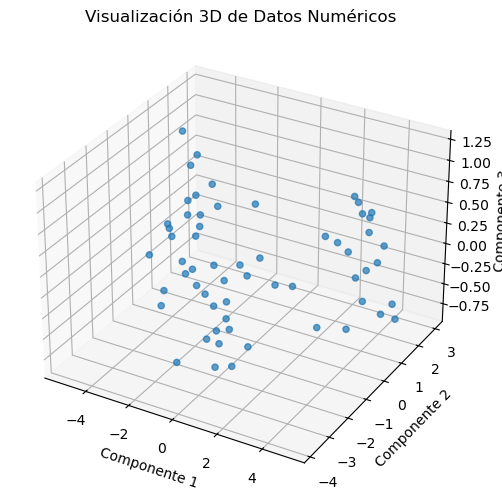

In [ ]:
#Este código no es estrictamente necesario, pero si el dataset cuenta con más de 3 dimensiones, reduce a 3 para graficar y visualizar
n_dim = min(3, X_csv.shape[1])  #si hay menos de 3 dimensiones, usamos lo que hay
pca = PCA(n_components=n_dim)
X_pca = pca.fit_transform(X_csv)

#Grafica según la dimensión
if n_dim == 1:
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], np.zeros_like(X_pca[:,0]), alpha=0.7)
    plt.xlabel('Componente 1')
    plt.title('Visualización 1D de Datos Numéricos')
    plt.grid(True)
    plt.show()
elif n_dim == 2:
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    plt.xlabel('Componente 1')
    plt.ylabel('Componente 2')
    plt.title('Visualización 2D de Datos Numéricos')
    plt.grid(True)
    plt.show()
else:  # 3D
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], alpha=0.7)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')
    ax.set_zlabel('Componente 3')
    ax.set_title('Visualización 3D de Datos Numéricos')
    plt.show()

In [ ]:
#Dendograma distancia Euclídea
Z_euclidean = linkage(X_csv, method='single', metric='euclidean')

plt.figure(figsize=(12,6))
dendrogram(Z_euclidean)
plt.title('Dendrograma - Distancia Euclídea')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

NameError: name 'linkage' is not defined

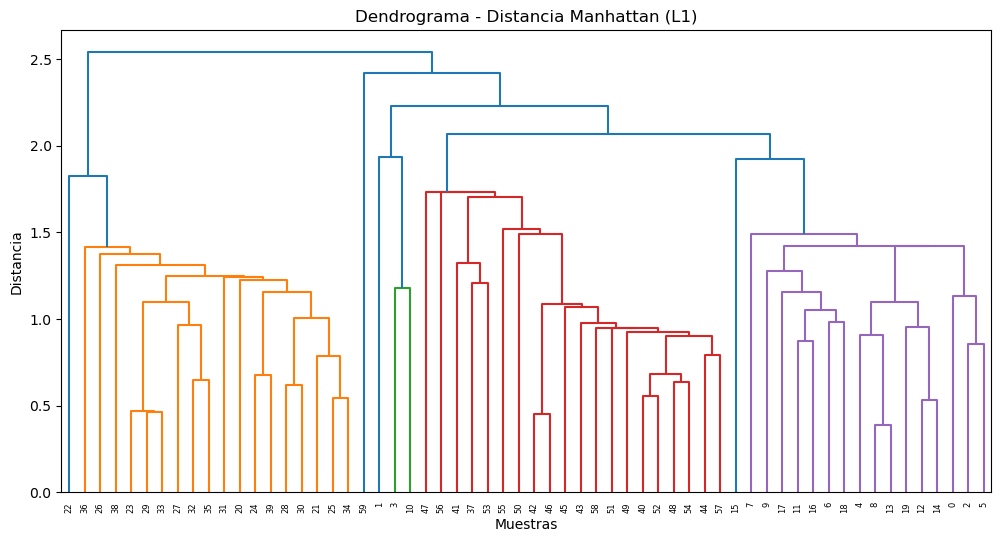

In [ ]:
#Dendograma con distancia Manhattan
Z_manhattan = linkage(X_csv, method='single', metric='cityblock')

plt.figure(figsize=(12,6))
dendrogram(Z_manhattan)
plt.title('Dendrograma - Distancia Manhattan (L1)')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

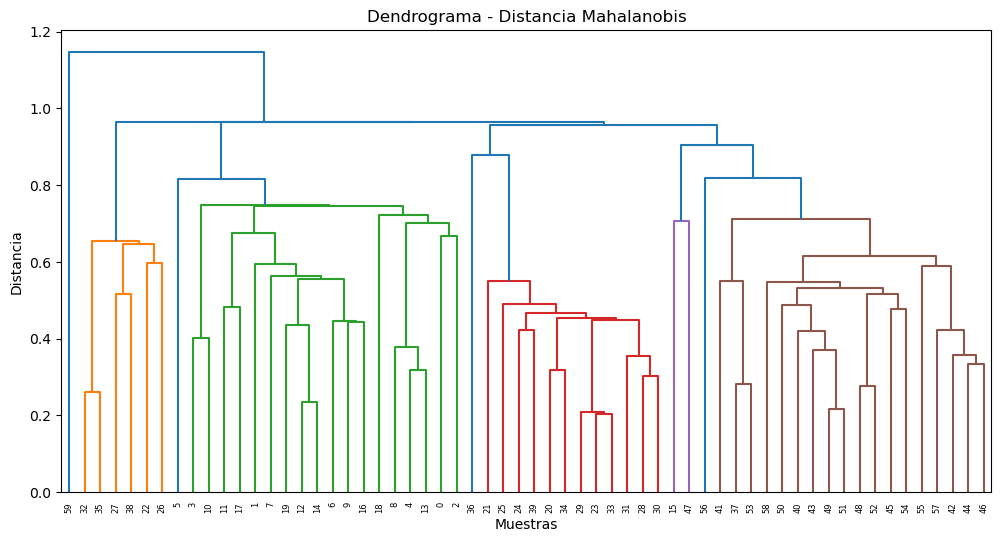

In [ ]:
# Distancia de Mahalanobis
#Calculamos la matriz de covarianza y la invertimos para la fórmula de la distancia de Mahal.
VI = np.linalg.inv(np.cov(X_csv.T))

#Calcula las distancias de Mahalanobis entre los puntos con la matriz de covarianzas invertida
D_mahal = pdist(X_csv, metric='mahalanobis', VI=VI)

#Hace el algoritmo con la distancia de Mahalanobis
Z_mahal = linkage(D_mahal, method='single')

plt.figure(figsize=(12,6))
dendrogram(Z_mahal)
plt.title('Dendrograma - Distancia Mahalanobis')
plt.xlabel('Muestras')
plt.ylabel('Distancia')
plt.show()

In [ ]:
linkages = {'Euclídea': Z_euclidean,
            'Manhattan': Z_manhattan,
            'Mahalanobis': Z_mahal}

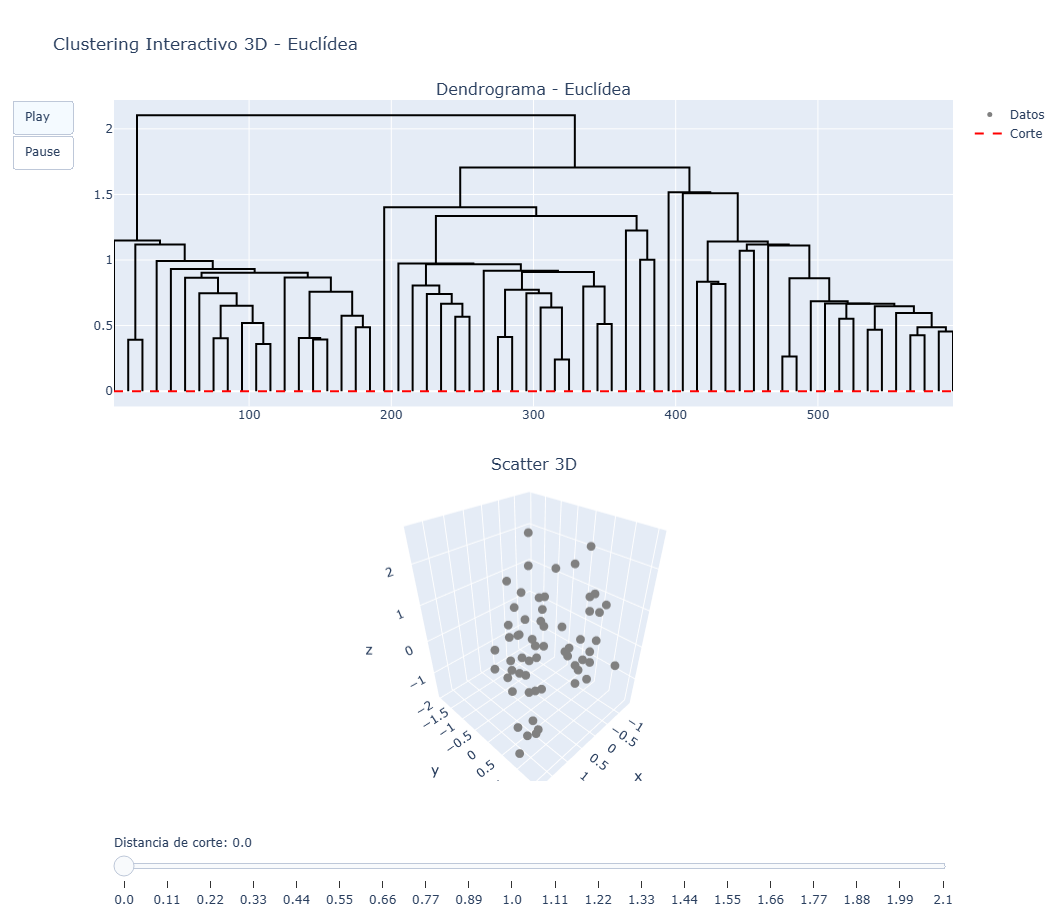

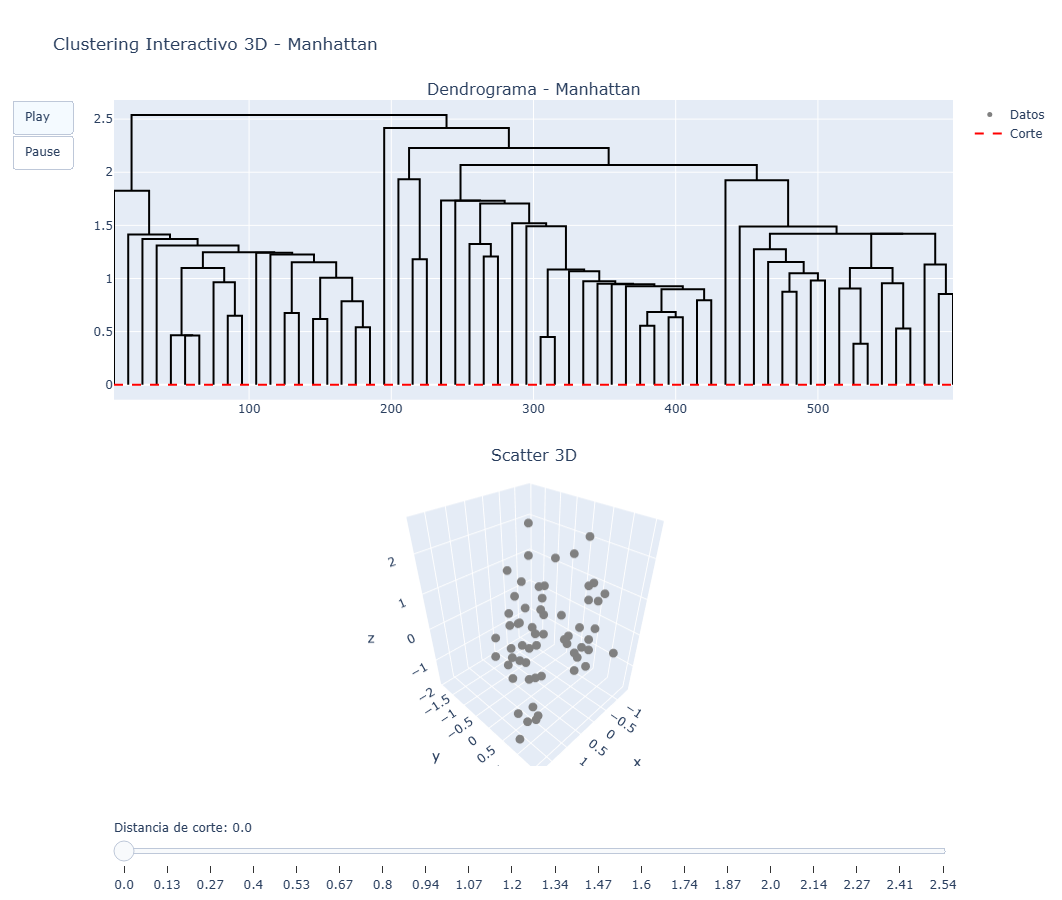

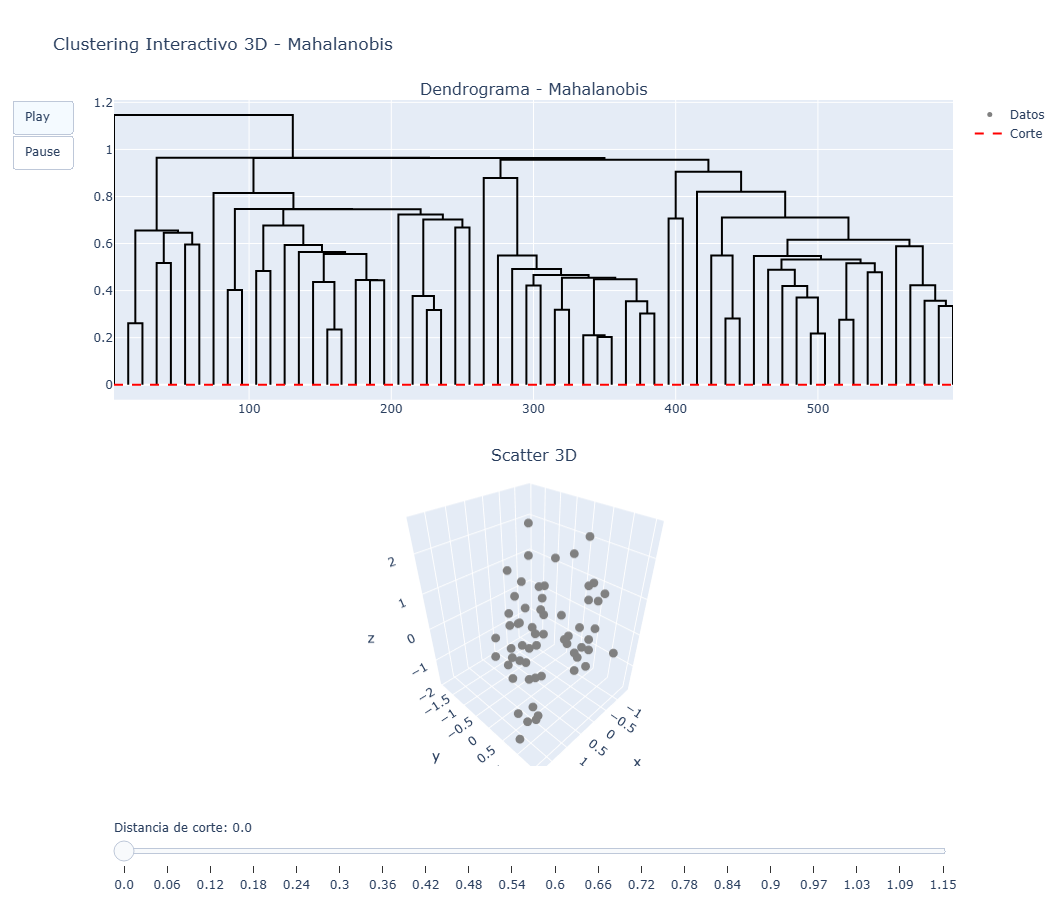

In [ ]:
#Para visualización 3D: si menos de 3 columnas, agregamos ceros
#Paleta de colores Plotly
palette = px.colors.qualitative.Plotly
n_colors = len(palette)

    #Este chunk de código sirve para transformar los 9 colores de plotlib a un sistema Hex con más colores (para mejor visualización) 
def matplotlib_color_to_hex(c):
    if c.startswith('C'):
        cmap = plt.get_cmap('tab10')  # Matplotlib tab10: C0..C9
        idx = int(c[1:])
        return mcolors.to_hex(cmap(idx))
    return c


#TODO LO QUE VIENE EN ADELANTE SIRVE PARA EL PLOT INTERACTIVO DENDOGRAMA-SCATTERPLOT 
def create_frames_colored(Z, X_scaled, n_steps=20):
    max_dist = np.max(Z[:,2])
    distances = np.linspace(0, max_dist, n_steps)
    frames = []

    dendro_full = dendrogram(Z, no_plot=True)
    icoord, dcoord = dendro_full['icoord'], dendro_full['dcoord']
    x_min = min([min(x) for x in icoord])
    x_max = max([max(x) for x in icoord])

    for d in distances:
        #Esto es para determinar los clusters
        clusters = fcluster(Z, t=d, criterion='distance')
        cluster_colors = [palette[(c-1)%n_colors] for c in clusters]

        #Esto es el dibujo en 3D
        scatter = go.Scatter3d(
            x=X_scaled[:,0],
            y=X_scaled[:,1],
            z=X_scaled[:,2],
            mode='markers',
            marker=dict(size=5, color=cluster_colors),
            name='Puntos'
        )

        #Esto es para colorear el dendograma de la gráfica
        dendro = dendrogram(Z, no_plot=True, color_threshold=d)
        icoord_d, dcoord_d, color_list = dendro['icoord'], dendro['dcoord'], dendro['color_list']

        dendro_lines = [go.Scatter(
            x=x, y=y,
            mode='lines',
            line=dict(color=matplotlib_color_to_hex(c), width=2),
            showlegend=False
        ) for x,y,c in zip(icoord_d,dcoord_d,color_list)]

        #Esto determina la recta (visualmente discontinua) de nivel de distancia del dendograma para determinar clusters
        cutoff_line = go.Scatter(
            x=[x_min, x_max],
            y=[d,d],
            mode='lines',
            line=dict(color='red', width=2, dash='dash'),
            name='Corte'
        )

        frames.append(go.Frame(data=[scatter] + dendro_lines + [cutoff_line], name=str(round(d,2))))

    return frames, distances #Nos da tanto el dendograma como el plot 3d (scatter) interactivo

    #Esto ejecuta la anterior función para cada linkage (L1,L2,Mahal)
for metric, Z in linkages.items():
    frames, distances = create_frames_colored(Z, X_scaled, n_steps=20)

    fig = make_subplots(
        rows=2, cols=1,
        row_heights=[0.5,0.5],
        vertical_spacing=0.1,
        specs=[[{}], [{"type":"scene"}]],
        subplot_titles=[f"Dendrograma - {metric}", "Scatter 3D"]
    )

    #Los colores iniciales de los puntos son grises y van adquiriendo color segíun formen clusters (aunque parece no funcionar)
    fig.add_trace(go.Scatter3d(
        x=X_scaled[:,0],
        y=X_scaled[:,1],
        z=X_scaled[:,2],
        mode='markers',
        marker=dict(size=5, color='gray'),
        name='Datos'
    ), row=2, col=1)

    #Dendrograma inicial
    dendro = dendrogram(Z, no_plot=True)
    icoord, dcoord = dendro['icoord'], dendro['dcoord']
    for x, y in zip(icoord, dcoord):
        fig.add_trace(go.Scatter(
            x=x,
            y=y,
            mode='lines',
            line=dict(color='black'),
            showlegend=False
        ), row=1, col=1)

    #Línea de corte inicial
    x_min = min([min(x) for x in icoord])
    x_max = max([max(x) for x in icoord])
    fig.add_trace(go.Scatter(
        x=[x_min, x_max],
        y=[0,0],
        mode='lines',
        line=dict(color='red', width=2, dash='dash'),
        name='Corte'
    ), row=1, col=1)

    #Frames
    fig.frames = frames

    #Barra deslizadora
    sliders = [dict(
        active=0,
        currentvalue={"prefix":"Distancia de corte: "},
        pad={"t":50},
        steps=[dict(method='animate',
                    args=[[str(round(d,2))],
                          dict(mode='immediate',
                               frame=dict(duration=500, redraw=True),
                               transition=dict(duration=0))],
                    label=str(round(d,2))) for d in distances]
    )]

    fig.update_layout(
        height=900,
        title_text=f"Clustering Interactivo 3D - {metric}",
        sliders=sliders,
        updatemenus=[dict(type="buttons",
                          buttons=[dict(label="Play",
                                        method="animate",
                                        args=[None, dict(frame=dict(duration=500, redraw=True),
                                                         fromcurrent=True,
                                                         mode='immediate')]),
                                   dict(label="Pause",
                                        method="animate",
                                        args=[[None], dict(frame=dict(duration=0, redraw=False),
                                                           mode='immediate')])])]
    )

    fig.show()

In [ ]:
import pandas as pd
import numpy as np

# Semilla para reproducibilidad
np.random.seed(42)

# Generar 3 clusters sintéticos en 2D
cluster1 = np.random.randn(20, 2) + [0, 0]
cluster2 = np.random.randn(20, 2) + [5, 5]
cluster3 = np.random.randn(20, 2) + [0, 5]

# Combinar todos los clusters
data = np.vstack([cluster1, cluster2, cluster3])

# Crear DataFrame
df = pd.DataFrame(data, columns=['X1', 'X2'])

# Opcional: agregar otra variable numérica para probar clustering en más dimensiones
df['X3'] = np.random.randn(df.shape[0]) * 0.5 + 2

# Guardar como CSV
df.to_csv("datos.csv", index=False)

print("Archivo 'datos.csv' generado con éxito.")
print(df.head())

In [ ]:
linkages

In [ ]:
plt.figure(figsize=(18,5))

# Euclídea
plt.subplot(1,3,1)
dendrogram(Z_euclidean)
plt.title("Dendrograma - Distancia Euclídea")
plt.xlabel("Muestras")
plt.ylabel("Distancia")

# Manhattan
plt.subplot(1,3,2)
dendrogram(Z_manhattan)
plt.title("Dendrograma - Distancia Manhattan (L1)")
plt.xlabel("Muestras")
plt.ylabel("Distancia")

# Mahalanobis
plt.subplot(1,3,3)
dendrogram(Z_mahal)
plt.title("Dendrograma - Distancia Mahalanobis")
plt.xlabel("Muestras")
plt.ylabel("Distancia")

plt.tight_layout()
plt.show()